In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [2]:
a = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\grid\grid_0.050_0.050.parquet")

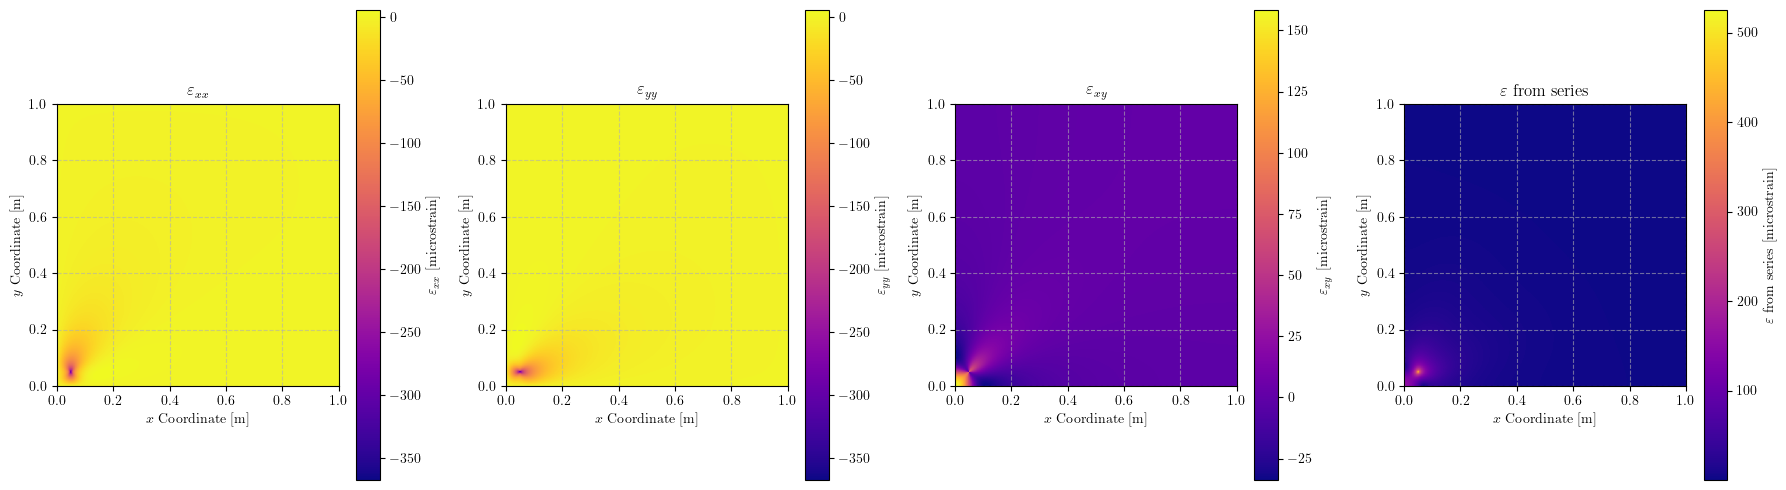

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EXX': a['EXX'],
    'EYY': a['EYY'],
    'EXY': a['EXY'],
    'EPS': a['EPS'],
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EXX', 'EYY', 'EXY', 'EPS']
strain_symbol = [r'$\varepsilon_{xx}$', r'$\varepsilon_{yy}$', r'$\varepsilon_{xy}$', r'$\varepsilon$ from series']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy() * 1e6

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{strain_symbol[i]}"+ r" $\left[\mathrm{microstrain}\right]$")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{strain_symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

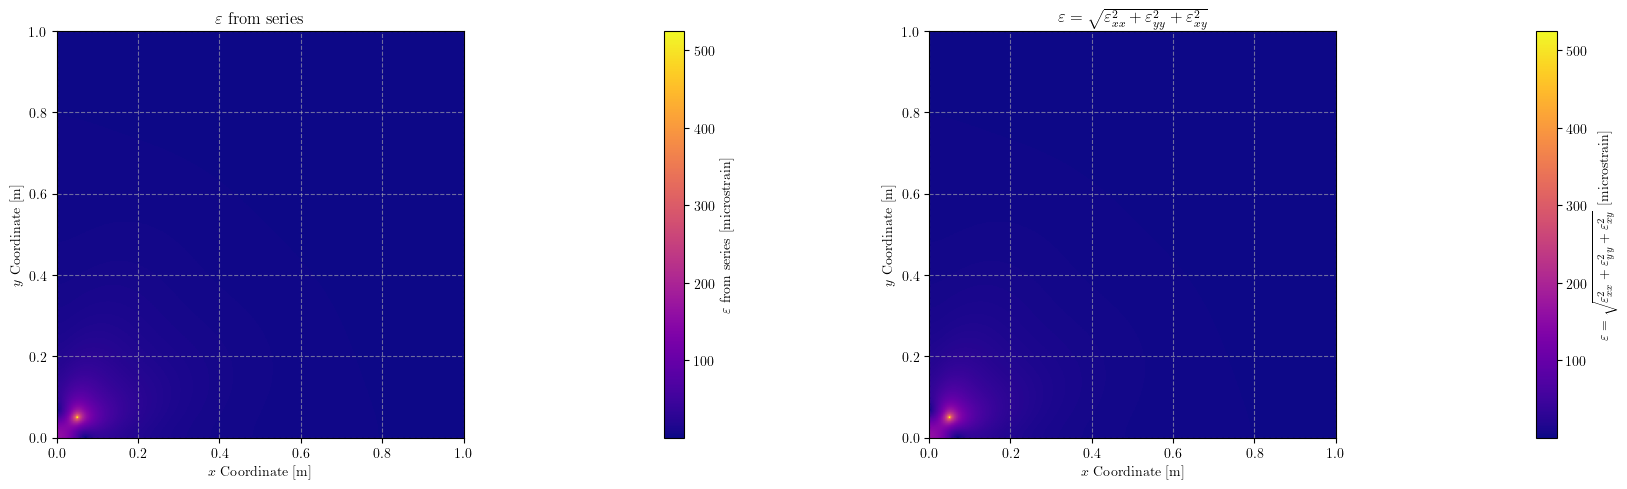

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EPS': a['EPS'],
    'EPSS': np.sqrt(a['EXX']**2 + a['EYY']**2 + a['EXY']**2),
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EPS', 'EPSS']
strain_symbol = [r'$\varepsilon$ from series', r'$\varepsilon = \sqrt{\varepsilon_{xx}^2 + \varepsilon_{yy}^2 + \varepsilon_{xy}^2}$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy() * 1e6

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{strain_symbol[i]}"+ r" $\left[\mathrm{microstrain}\right]$")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{strain_symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

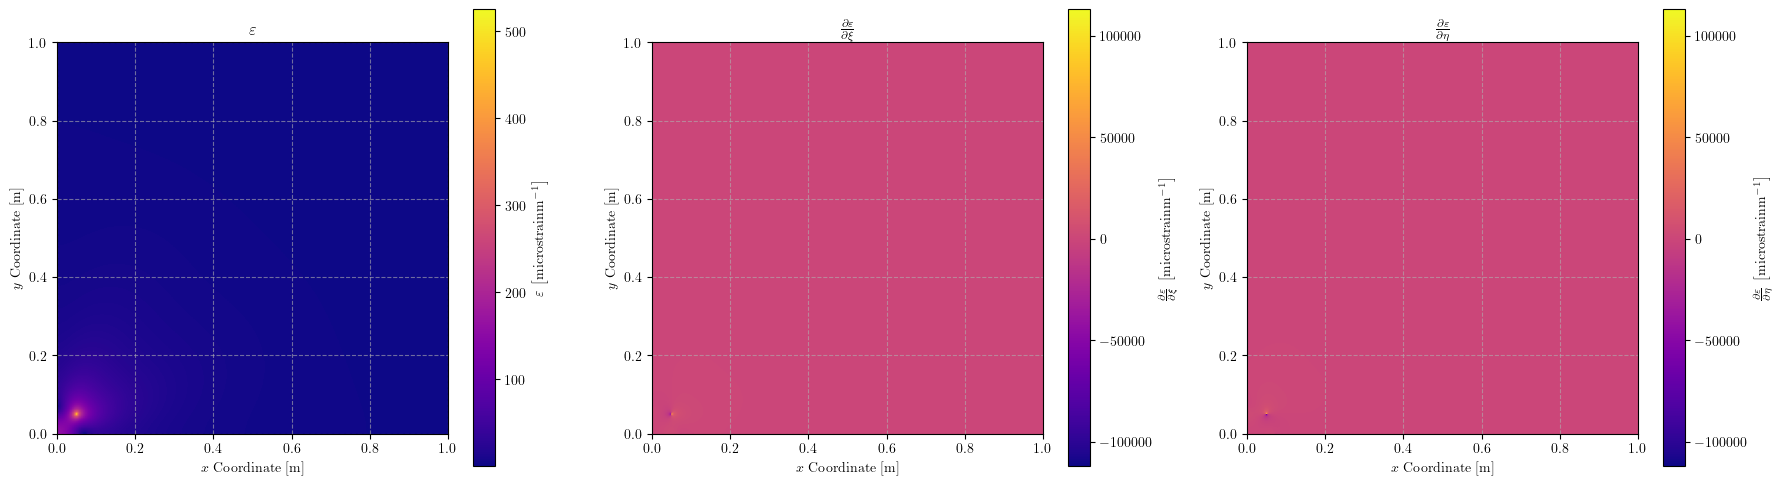

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'EPS': a['EPS'],
    'EPS_XI': a['EPS_XI'],
    'EPS_ETA': a['EPS_ETA'],
})

# Define the components to iterate over to avoid repeating code
strain_components = ['EPS', 'EPS_XI', 'EPS_ETA']
strain_symbol = [r'$\varepsilon$', r'$\frac{\partial \varepsilon}{\partial \xi}$', r'$\frac{\partial \varepsilon}{\partial \eta}$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy() * 1e6

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{strain_symbol[i]}"+ r" $\left[\mathrm{microstrain m^{-1}}\right]$")
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{strain_symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

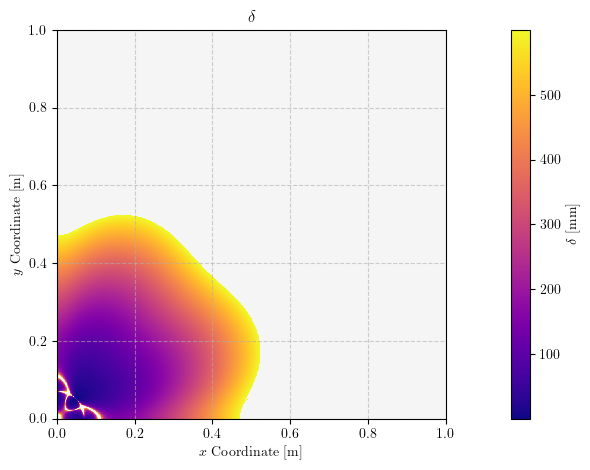

In [11]:
fig, ax = plt.subplots()

delta_thr = 10e-5

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'delta': delta_thr / abs(a['EPS_ETA'] + a['EPS_XI']),
})

diff_pivot = diff_df.pivot(index='Y', columns='X', values='delta')

x_coords = diff_pivot.columns.to_numpy()
y_coords = diff_pivot.index.to_numpy()
C = diff_pivot.to_numpy()

display_threshold = 0.6
C_masked = np.ma.masked_greater(C, display_threshold)

cmap = plt.get_cmap("plasma").copy()
cmap.set_bad(color='whitesmoke') 


X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

# Plot the pcolormesh specifically on the current axis (ax[i])
colormesh = ax.pcolormesh(X_mesh, Y_mesh, C_masked * 1e3, cmap=cmap, shading='auto', rasterized=True)

# Add colorbar to the figure, specifying which axis it belongs to
cbar = fig.colorbar(colormesh, ax=ax, label=f"$\\delta$"+ r" $\left[\mathrm{mm}\right]$")

# Use 'set_' methods for axis properties
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_title(f"$\\delta$")
ax.axis("scaled") # Ensures the geometry isn't distorted
ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [7]:
print(np.min(diff_df['delta']))

0.000446312909501615


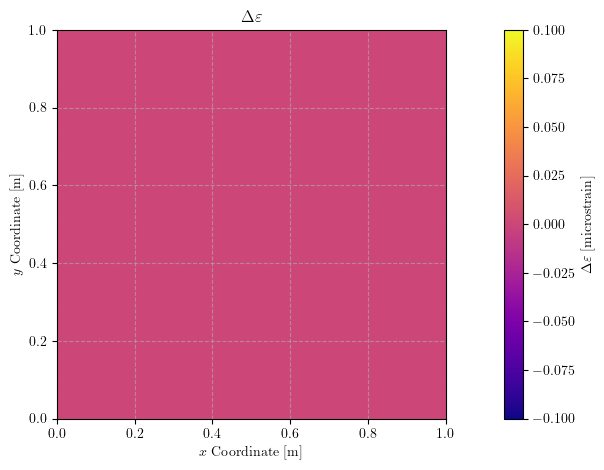

In [8]:
fig, ax = plt.subplots()

# Prepare data for pivoting
diff_df = pd.DataFrame({
    'X': a['X'],
    'Y': a['Y'],
    'delta': np.sqrt(a['EXX']**2 + a['EYY']**2 + a['EXY']**2) - a['EPS'],
})

# Define the components to iterate over to avoid repeating code
strain_components = ['delta']
strain_symbol = [r'$\Delta \varepsilon$']

for i, component in enumerate(strain_components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = diff_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy() * 1e6

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax.pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax, label=f"{strain_symbol[i]}"+ r" $\left[\mathrm{microstrain}\right]$")
    
    # Use 'set_' methods for axis properties
    ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax.set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax.set_title(f"{strain_symbol[i]}")
    ax.axis("scaled") # Ensures the geometry isn't distorted
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()